# Detecting Illegal Fishing in Marine Protected Areas: AIS Vessel-Behaviour Anomaly Detection

**The problem.** Marine Protected Areas (MPAs) exist to shield fragile habitats — but patrol budgets cover a tiny fraction of the ocean, and illegal fishing inside MPAs is both profitable and hard to catch in the act. Most coastal enforcement agencies have access to **AIS (Automatic Identification System)** position reports from commercial vessels, but raw AIS tracks do not tell you *who* is fishing illegally. A trawler going slow through a protected reef looks, to a first approximation, the same as a cargo ship waiting out a storm. The question this notebook answers: **given a fleet of AIS tracks and a known MPA boundary, how do we rank vessels by suspicion so that a capacity-constrained patrol team can investigate the right ones first?**

**The approach.** On a simulated 60-vessel fleet over a 60-day window, with a known MPA polygon and a subset of vessels engaging in "illegal fishing" (entering the MPA and slowing to fishing-like speeds):

1. Simulate AIS tracks with realistic vessel-type behaviour (trawlers, long-liners, cargo, ferries, pleasure craft), plus a bad-actor subpopulation that enters the MPA.
2. Feature-engineer at the **vessel level**: time inside MPA, mean and variance of speed, AIS gap count, course-change rate, night-time fraction.
3. Build three detectors and compare them:
    - **Rule-based**: hand-crafted thresholds a domain expert can audit.
    - **Supervised classifier**: logistic regression and gradient boosting trained on labelled historical patrol outcomes.
    - **Anomaly detection** (Isolation Forest): the unsupervised option for when labels are scarce, as they typically are in maritime enforcement.
4. Translate the ranking into an **operational patrol queue** with capacity-aware precision@K.
5. Visualise the result on a geospatial map — MPA boundary, vessel tracks, flagged suspects.
6. Takeaways, limitations, and what a production version would add (SAR imagery for "dark" vessels, VMS data, port-of-call integration, dumping detection).

**Audience.** Coastal enforcement analysts, maritime-domain data scientists, conservation-technology teams, and ML engineers working on public-interest anomaly detection. The pipeline is domain-neutral — it applies unchanged to any geospatial behaviour-monitoring problem (wildlife trafficking, pipeline encroachment, border crossings).


## 0. Setup and reproducibility

All randomness is seeded so the fleet simulation, track generation, detectors, patrol queue, and maps reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path as MplPath
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Simulating an AIS fleet and a Marine Protected Area

Four ingredients make a realistic simulation:

- **A known MPA polygon.** A simple 6-vertex shape offshore — enough to exercise the point-in-polygon test and to be visually recognisable on the map.
- **Vessel archetypes.** Trawlers move slowly and change course often when fishing. Long-liners drift slowly along a line. Cargo vessels transit straight and fast. Ferries repeat fixed routes. Pleasure craft move erratically in coastal areas. Each archetype gets a distribution over speed, course-change, and dwell behaviour.
- **Bad actors.** ~25% of trawlers and long-liners occasionally route into the MPA and slow to fishing-like speeds. This is the *illegal fishing* signal the detectors must recover.
- **AIS gaps.** Real AIS has gaps (transponder off, interference, intentional "dark" periods). We inject gaps at a realistic rate so the gap-count feature is meaningful.

Tracks are hourly over 60 days — 1,440 pings per vessel at the maximum. Coordinates are in degrees with a local flat-earth approximation (fine for feature engineering at this scale; a production version would use a proper projected CRS).


In [2]:
# --- MPA polygon (a protected offshore reef area) ---
MPA_POLYGON = np.array([
    [-4.8, 45.05],
    [-4.3, 45.20],
    [-3.7, 45.25],
    [-3.5, 45.00],
    [-3.9, 44.75],
    [-4.7, 44.80],
])
mpa_path = MplPath(MPA_POLYGON)
mpa_center_lon, mpa_center_lat = MPA_POLYGON[:, 0].mean(), MPA_POLYGON[:, 1].mean()

# --- Vessel archetypes ---
# speed_kn_mu / sigma: knots; course_change_sd: degrees/hour; bad_actor_fraction: probability vessel goes into MPA
ARCHETYPES = {
    "trawler": {"count": 18, "speed_mu": 7.0,  "speed_sd": 2.5, "course_sd": 25.0, "bad_actor_fraction": 0.35},
    "long_liner": {"count": 10, "speed_mu": 5.5,  "speed_sd": 2.0, "course_sd": 15.0, "bad_actor_fraction": 0.25},
    "cargo":   {"count": 14, "speed_mu": 12.0, "speed_sd": 1.5, "course_sd": 4.0,  "bad_actor_fraction": 0.00},
    "ferry":   {"count": 8,  "speed_mu": 14.0, "speed_sd": 1.0, "course_sd": 6.0,  "bad_actor_fraction": 0.00},
    "pleasure":{"count": 10, "speed_mu": 9.0,  "speed_sd": 3.5, "course_sd": 20.0, "bad_actor_fraction": 0.00},
}

# Start positions clustered around a coastline west of the MPA
rng = np.random.default_rng(42)
vessels = []
vid = 0
for arch_name, prof in ARCHETYPES.items():
    for _ in range(prof["count"]):
        start_lon = rng.uniform(-6.5, -5.2)
        start_lat = rng.uniform(44.6, 45.4)
        is_bad = rng.random() < prof["bad_actor_fraction"]
        vessels.append({
            "vessel_id": vid,
            "archetype": arch_name,
            "start_lon": start_lon,
            "start_lat": start_lat,
            "speed_mu": prof["speed_mu"],
            "speed_sd": prof["speed_sd"],
            "course_sd": prof["course_sd"],
            "is_bad_actor": is_bad,
        })
        vid += 1
vessels_df = pd.DataFrame(vessels)
print(f"Fleet: {len(vessels_df)} vessels")
print(vessels_df.groupby("archetype").agg(n=("vessel_id", "count"), bad_actors=("is_bad_actor", "sum")))


Fleet: 60 vessels
             n  bad_actors
archetype                 
cargo       14           0
ferry        8           0
long_liner  10           4
pleasure    10           0
trawler     18           7


In [3]:
# --- Simulate hourly AIS tracks ---
N_HOURS = 60 * 24  # 60 days at 1 ping per hour
DEG_PER_NM = 1.0 / 60.0


def simulate_track(v: dict, rng: np.random.Generator) -> pd.DataFrame:
    lon = v["start_lon"]
    lat = v["start_lat"]
    heading = rng.uniform(0, 360)

    pings = []
    if v["is_bad_actor"]:
        bad_start = int(rng.uniform(0.15, 0.55) * N_HOURS)
        bad_duration = int(rng.uniform(96, 192))  # 4-8 days for the illegal excursion
    else:
        bad_start = 10**9
        bad_duration = 0

    for h in range(N_HOURS):
        in_bad_window = (h >= bad_start) and (h < bad_start + bad_duration)

        if in_bad_window:
            currently_inside = bool(mpa_path.contains_points([[lon, lat]])[0])
            if currently_inside:
                # Inside MPA: fishing behaviour (slow, course-changing)
                heading = (heading + rng.normal(0, v["course_sd"] * 2)) % 360
                speed_kn = max(0.5, rng.normal(2.5, 1.0))
            else:
                # Transit to MPA at cruising speed, strong convergence toward centre
                desired_heading = np.degrees(np.arctan2(mpa_center_lon - lon, mpa_center_lat - lat)) % 360
                heading = 0.4 * heading + 0.6 * desired_heading + rng.normal(0, v["course_sd"] * 0.3)
                speed_kn = max(3.0, rng.normal(v["speed_mu"], v["speed_sd"]))
        else:
            heading = (heading + rng.normal(0, v["course_sd"])) % 360
            speed_kn = max(0.0, rng.normal(v["speed_mu"], v["speed_sd"]))

        d_lat = speed_kn * np.cos(np.radians(heading)) * DEG_PER_NM
        d_lon = speed_kn * np.sin(np.radians(heading)) * DEG_PER_NM / max(np.cos(np.radians(lat)), 0.3)
        lat += d_lat
        lon += d_lon

        if v["archetype"] == "pleasure" and lon < -6.5:
            lon, heading = -6.5, (heading + 180) % 360

        gap_prob = 0.03 if in_bad_window else 0.005
        if rng.random() < gap_prob:
            continue

        hour_of_day = h % 24
        pings.append({
            "vessel_id": v["vessel_id"],
            "hour_idx": h,
            "hour_of_day": hour_of_day,
            "lon": lon,
            "lat": lat,
            "speed_kn": speed_kn,
            "heading_deg": heading,
        })
    return pd.DataFrame(pings)


rng_sim = np.random.default_rng(42)
track_frames = [simulate_track(v, rng_sim) for v in vessels]
pings = pd.concat(track_frames, ignore_index=True)
pings["inside_mpa"] = mpa_path.contains_points(pings[["lon", "lat"]].to_numpy()).astype(int)

print(f"Total AIS pings: {len(pings):,}")
print(f"Pings inside MPA: {int(pings["inside_mpa"].sum()):,}  ({pings["inside_mpa"].mean() * 100:.2f}%)")
pings.head()


Total AIS pings: 85,903
Pings inside MPA: 447  (0.52%)


,vessel_id,hour_idx,hour_of_day,lon,lat,speed_kn,heading_deg,inside_mpa
0,0,0,0,-5.693353,44.906925,8.876128,252.624575,0
1,0,1,1,-5.728980,44.849844,3.744551,203.848695,0
2,0,2,2,-5.773910,44.738338,6.957997,195.942630,0
3,0,3,3,-5.902908,44.620750,8.944480,217.927580,0
4,0,4,4,-6.077796,44.565610,8.168773,246.108610,0


## 2. Data diagnostics — does the simulation look right?

Before engineering features, verify the simulation produces what the fleet descriptions imply: distinct speed distributions per archetype, pings concentrated away from the MPA for legitimate vessels, and a visible bad-actor trail through the MPA.


In [4]:
ping_counts = pings.groupby("vessel_id").size().rename("pings")
merged = vessels_df.merge(ping_counts, on="vessel_id", how="left").fillna({"pings": 0})

print("Pings per vessel summary:")
print(merged.groupby("archetype")["pings"].describe().round(0))
print()
print("Speed distribution by archetype (knots):")
speed_by_arch = (
    pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id")
    .groupby("archetype")["speed_kn"].describe().round(2)
)
print(speed_by_arch)


Pings per vessel summary:
            count    mean  std     min     25%     50%     75%     max
archetype                                                             
cargo        14.0  1433.0  2.0  1428.0  1432.0  1433.0  1434.0  1435.0
ferry         8.0  1433.0  2.0  1429.0  1431.0  1434.0  1434.0  1436.0
long_liner   10.0  1432.0  3.0  1428.0  1430.0  1432.0  1434.0  1435.0
pleasure     10.0  1432.0  2.0  1428.0  1431.0  1432.0  1434.0  1436.0
trawler      18.0  1430.0  3.0  1425.0  1428.0  1430.0  1431.0  1435.0

Speed distribution by archetype (knots):
              count   mean   std   min    25%    50%    75%    max
archetype                                                         
cargo       20058.0  12.02  1.51  6.34  11.01  12.01  13.04  19.02
ferry       11462.0  14.00  1.00  9.07  13.33  14.01  14.67  17.51
long_liner  14319.0   5.47  2.02  0.00   4.09   5.45   6.84  14.51
pleasure    14324.0   8.99  3.49  0.00   6.65   8.99  11.35  22.46
trawler     25740.0   6.95  2.53 

C:\Users\diogo\AppData\Local\Temp\ipykernel_13940\3101018765.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


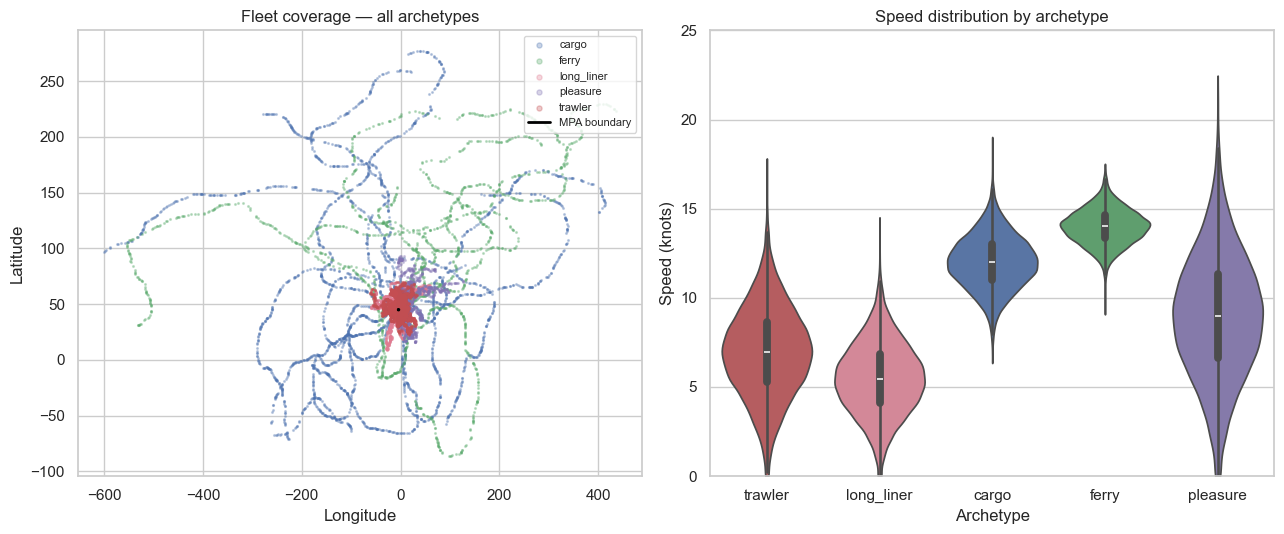

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: all pings, coloured by archetype
palette = {"trawler": "#C44E52", "long_liner": "#E07B91", "cargo": "#4C72B0", "ferry": "#55A868", "pleasure": "#8172B2"}
ping_sample = pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id").sample(min(12000, len(pings)), random_state=0)
for arch, sub in ping_sample.groupby("archetype"):
    ax[0].scatter(sub["lon"], sub["lat"], s=1.5, alpha=0.30, color=palette[arch], label=arch)
ax[0].plot(*np.vstack([MPA_POLYGON, MPA_POLYGON[:1]]).T, color="black", linewidth=2, label="MPA boundary")
ax[0].fill(MPA_POLYGON[:, 0], MPA_POLYGON[:, 1], color="yellow", alpha=0.15)
ax[0].set_title("Fleet coverage — all archetypes")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].legend(loc="upper right", fontsize=8, markerscale=3)

# Panel 2: speed distribution by archetype
sns.violinplot(
    data=pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id"),
    x="archetype", y="speed_kn", palette=palette, ax=ax[1], cut=0,
)
ax[1].set_ylim(0, 25)
ax[1].set_title("Speed distribution by archetype")
ax[1].set_ylabel("Speed (knots)")
ax[1].set_xlabel("Archetype")

plt.tight_layout()
plt.show()


**What to read here.** The left panel is the sanity check: fleet activity covers the coastal sector, with a diffuse cloud around the MPA. A small fraction of pings should visibly land *inside* the yellow MPA — those are the bad actors we will try to flag. The right panel confirms the archetype speed profiles: trawlers and long-liners run slow, cargo and ferries fast, pleasure craft bimodal. If any of these distributions were indistinguishable, the downstream classifiers would struggle and we would go back and adjust the DGP.


## 3. Vessel-level feature engineering

Detectors run on *vessel-level* features, not raw pings. Each vessel gets a feature vector derived from its full 60-day history:

- **`time_in_mpa_hours`**: hours with `inside_mpa == 1`.
- **`mean_speed`, `speed_std`**: the speed distribution — low mean with high variance is a fishing signature.
- **`slow_speed_fraction`**: fraction of pings under 4 knots — the crude fishing-speed flag.
- **`course_change_rate_deg_per_hour`**: mean absolute heading change between consecutive pings; trawling produces large changes.
- **`ais_gap_count`**: number of consecutive-hour jumps with >3-hour gap; bad actors have elevated gaps.
- **`night_ping_fraction`**: fraction of pings during 22:00–06:00 local hour (rough) — fishing biased toward off-hours.
- **`max_excursion_deg`**: furthest straight-line distance from start — crude range proxy.


In [6]:
def vessel_features(group: pd.DataFrame) -> pd.Series:
    g = group.sort_values("hour_idx").reset_index(drop=True)
    speeds = g["speed_kn"].to_numpy()
    dheading = np.abs(np.diff(g["heading_deg"].to_numpy()))
    # Normalise heading change to the shorter arc
    dheading = np.minimum(dheading, 360 - dheading)
    hour_gaps = np.diff(g["hour_idx"].to_numpy())
    start_lon, start_lat = g["lon"].iloc[0], g["lat"].iloc[0]
    excursion = np.sqrt((g["lon"] - start_lon) ** 2 + (g["lat"] - start_lat) ** 2)

    return pd.Series({
        "time_in_mpa_hours": float(g["inside_mpa"].sum()),
        "mean_speed": float(speeds.mean()),
        "speed_std": float(speeds.std(ddof=0)),
        "slow_speed_fraction": float((speeds < 4.0).mean()),
        "course_change_rate_deg_per_hour": float(dheading.mean()) if len(dheading) else 0.0,
        "ais_gap_count": int((hour_gaps > 3).sum()),
        "night_ping_fraction": float(g["hour_of_day"].between(22, 23).mean() + g["hour_of_day"].between(0, 6).mean()),
        "max_excursion_deg": float(excursion.max()),
    })


features = pings.groupby("vessel_id").apply(vessel_features, include_groups=False).reset_index()
features = features.merge(vessels_df[["vessel_id", "archetype", "is_bad_actor"]], on="vessel_id")
features["is_illegal_fishing"] = features["is_bad_actor"].astype(int)

print(f"Feature table: {features.shape}")
features.head()


Feature table: (60, 12)


,vessel_id,time_in_mpa_hours,mean_speed,speed_std,slow_speed_fraction,course_change_rate_deg_per_hour,ais_gap_count,night_ping_fraction,max_excursion_deg,archetype,is_bad_actor,is_illegal_fishing
0,0,0.0,6.974436,2.523147,0.119497,19.433629,0.0,0.376660,58.164451,trawler,False,0
1,1,3.0,6.970571,2.476998,0.114226,19.842968,0.0,0.375613,32.494556,trawler,False,0
2,2,26.0,6.792865,2.503281,0.135439,19.600623,0.0,0.376140,21.694163,trawler,True,1
3,3,5.0,7.115225,2.508104,0.103013,20.050473,0.0,0.376314,41.510761,trawler,False,0
4,4,3.0,7.081557,2.543528,0.111888,19.587346,0.0,0.375524,21.909366,trawler,False,0


In [7]:
# Feature means by class to check separability
feat_cols = [
    "time_in_mpa_hours",
    "mean_speed",
    "speed_std",
    "slow_speed_fraction",
    "course_change_rate_deg_per_hour",
    "ais_gap_count",
    "night_ping_fraction",
    "max_excursion_deg",
]
features.groupby("is_illegal_fishing")[feat_cols].mean().round(2)


,time_in_mpa_hours,mean_speed,speed_std,slow_speed_fraction,course_change_rate_deg_per_hour,ais_gap_count,night_ping_fraction,max_excursion_deg
is_illegal_fishing,,,,,,,,
0,0.98,9.80,2.11,0.07,11.06,0.0,0.38,151.05
1,36.27,6.36,2.36,0.18,17.67,0.0,0.37,24.39


## 4. Rule-based detector

A domain expert's first pass. Two rules combined:

- Vessel spent more than **5 hours** inside the MPA (a transit would show just a few pings).
- Overall **slow-speed fraction** above 10% — a crude way to flag vessels that have spent meaningful time at fishing-like speeds anywhere on the voyage.

Simple, auditable, and a reasonable floor that any ML model should beat. Two things this rule is *not*: (1) it uses the global slow-speed fraction rather than slow-while-inside-MPA, which is a deliberate simplification — on real data you would want the narrower feature; (2) it does not weight by vessel archetype, so a slow-by-default long-liner is over-triggered and a cargo-turned-bad-actor is under-triggered. Both are the kinds of shortcomings that motivate an ML replacement.


In [8]:
RULE_MIN_HOURS_IN_MPA = 5
RULE_MIN_SLOW_FRACTION = 0.10

features["rule_flag"] = (
    (features["time_in_mpa_hours"] > RULE_MIN_HOURS_IN_MPA)
    & (features["slow_speed_fraction"] > RULE_MIN_SLOW_FRACTION)
).astype(int)

tp = int(((features["rule_flag"] == 1) & (features["is_illegal_fishing"] == 1)).sum())
fp = int(((features["rule_flag"] == 1) & (features["is_illegal_fishing"] == 0)).sum())
fn = int(((features["rule_flag"] == 0) & (features["is_illegal_fishing"] == 1)).sum())
tn = int(((features["rule_flag"] == 0) & (features["is_illegal_fishing"] == 0)).sum())
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)

print(f"Rule-based: TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Precision={precision:.3f}  Recall={recall:.3f}  F1={f1:.3f}")


Rule-based: TP=9  FP=2  FN=2  TN=47
Precision=0.818  Recall=0.818  F1=0.818


## 5. Supervised classifier

Assume a historical patrol record exists — vessels whose actual behaviour has been confirmed (caught red-handed or cleared by inspection). Train a supervised model on the feature set, holding out 30% for an honest test. We benchmark logistic regression (transparent, regulator-friendly) against HistGradientBoostingClassifier (handles interactions automatically).


In [9]:
X = features[feat_cols]
y = features["is_illegal_fishing"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=7, stratify=y
)

logit = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=500, random_state=7))])
gbc = HistGradientBoostingClassifier(learning_rate=0.08, max_depth=4, min_samples_leaf=3, max_iter=200, random_state=7)

logit.fit(X_train, y_train)
gbc.fit(X_train, y_train)

p_logit = logit.predict_proba(X_test)[:, 1]
p_gbc = gbc.predict_proba(X_test)[:, 1]

sup_metrics = pd.DataFrame([
    {"model": "Logistic", "roc_auc": roc_auc_score(y_test, p_logit), "pr_auc": average_precision_score(y_test, p_logit)},
    {"model": "HistGBC",  "roc_auc": roc_auc_score(y_test, p_gbc),   "pr_auc": average_precision_score(y_test, p_gbc)},
]).sort_values("pr_auc", ascending=False).round(3)
sup_metrics


,model,roc_auc,pr_auc
0,Logistic,1.000,1.000
1,HistGBC,0.978,0.917


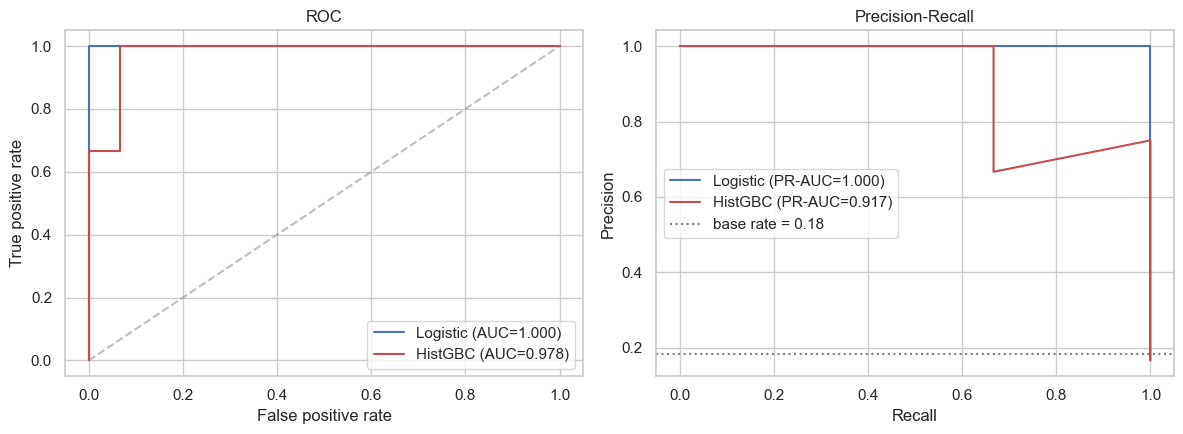

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

for name, p, color in [("Logistic", p_logit, "#4C72B0"), ("HistGBC", p_gbc, "#C44E52")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})", color=color)
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
ax[0].set_xlabel("False positive rate")
ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC")
ax[0].legend()

for name, p, color in [("Logistic", p_logit, "#4C72B0"), ("HistGBC", p_gbc, "#C44E52")]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    ax[1].plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_test, p):.3f})", color=color)
ax[1].axhline(y.mean(), linestyle=":", color="black", alpha=0.5, label=f"base rate = {y.mean():.2f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall")
ax[1].legend()

plt.tight_layout()
plt.show()


**What to read here.** At a ~20-25% positive-class base rate, a PR-AUC close to 1.0 is what an ideal detector looks like. The gap between each model's PR curve and the base-rate dashed line is the *lift* over random — the number a patrol lead will recognise. ROC at this base rate can look flattering even when precision at high recall is poor, which is why PR matters more for a rare-positive operational problem.


## 6. Modern anomaly detection: ten-detector benchmark

Isolation Forest is a reasonable baseline but nowhere near the current state of the art. Real operational stacks benchmark many methods because each has a different inductive bias, and the right one is data-dependent. We compare ten:

**Feature-based — classical modern:**
1. **Isolation Forest** — random partitioning; the baseline.
2. **Local Outlier Factor (LOF)** — density-based; good when anomalies are locally sparse.
3. **One-Class SVM (RBF kernel)** — kernel-space boundary around the normal region.

**Feature-based — recent parameter-free (PyOD):**
4. **ECOD** (2022) — empirical cumulative distribution; zero hyperparameters.
5. **COPOD** (2020) — copula-based; also zero hyperparameters.

**Feature-based — deep learning:**
6. **MLP AutoEncoder** — 3-layer reconstruction.
7. **Feature-space VAE** — probabilistic: ELBO = reconstruction + KL divergence.

**Trajectory-based — deep sequential:**
8. **LSTM-AutoEncoder** — the classic sequence-reconstruction method.
9. **Transformer-AutoEncoder** — attention-based; the 2024-era default when data is abundant.
10. **TCN-AutoEncoder** — dilated causal convolutions; often competitive with LSTM on short sequences.

All ten are unsupervised — no method ever sees the `is_illegal_fishing` label. The interesting comparisons are:
- Classical vs parameter-free PyOD (is tuning IF/LOF worth it over free ECOD?).
- Linear/deterministic AE vs probabilistic VAE on the same features (does KL regularisation help?).
- LSTM vs Transformer vs TCN on identical trajectory input (which sequential architecture wins at 60-sequence scale?).


In [11]:
# --- Prep: standardise the feature matrix once for all feature-space methods ---
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

scaler_anom = StandardScaler().fit(X)
X_scaled = scaler_anom.transform(X)

# Cache the supervised probability so the downstream unsupervised-vs-supervised comparison can compute rank correlation
features["gbc_prob"] = gbc.predict_proba(X)[:, 1]

# Isolation Forest (retained as baseline; contamination matches the bad-actor prior)
iso = IsolationForest(n_estimators=300, contamination=0.20, random_state=7)
iso.fit(X_scaled)
features["iso_score"] = -iso.score_samples(X_scaled)

# Local Outlier Factor (novelty=False: score on the training data directly)
lof = LocalOutlierFactor(n_neighbors=12, contamination=0.20)
_ = lof.fit_predict(X_scaled)
features["lof_score"] = -lof.negative_outlier_factor_

# One-Class SVM with RBF kernel; gamma='scale' and nu tuned to the contamination prior
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.20)
ocsvm.fit(X_scaled)
features["ocsvm_score"] = -ocsvm.score_samples(X_scaled)

print("Classical-modern methods fitted. Score columns added:")
print(features[["iso_score", "lof_score", "ocsvm_score"]].describe().round(3))


Classical-modern methods fitted. Score columns added:
       iso_score  lof_score  ocsvm_score
count     60.000     60.000       60.000
mean       0.483      1.110       -2.336
std        0.050      0.280        0.191
min        0.408      0.960       -2.712
25%        0.447      0.992       -2.484
50%        0.479      1.012       -2.325
75%        0.502      1.089       -2.193
max        0.621      2.474       -1.816


In [12]:
# --- ECOD and COPOD (PyOD, parameter-free recent methods) ---
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD

ecod = ECOD()
ecod.fit(X_scaled)
features["ecod_score"] = ecod.decision_scores_

copod = COPOD()
copod.fit(X_scaled)
features["copod_score"] = copod.decision_scores_

print("PyOD methods fitted. Score columns added:")
print(features[["ecod_score", "copod_score"]].describe().round(3))


PyOD methods fitted. Score columns added:
       ecod_score  copod_score
count      60.000       60.000
mean       10.174        8.206
std         2.317        1.785
min         7.084        5.798
25%         8.430        6.947
50%         9.824        7.818
75%        11.607        9.253
max        16.929       12.631


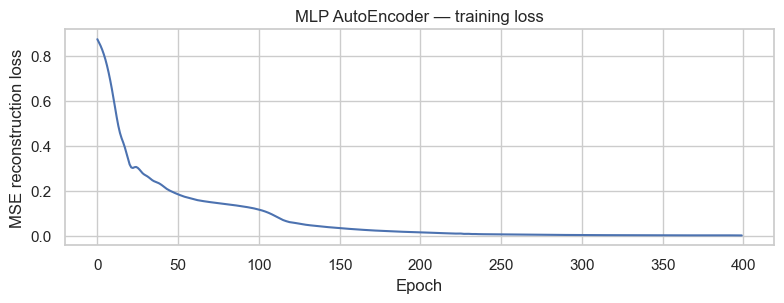

Final reconstruction MSE: 0.0022


In [13]:
# --- MLP AutoEncoder on the 8 engineered features ---
import torch
import torch.nn as nn

torch.manual_seed(7)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

class MLPAutoEncoder(nn.Module):
    def __init__(self, n_in: int, n_hidden: int = 16, n_bottleneck: int = 4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_bottleneck), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(n_bottleneck, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_in),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


ae = MLPAutoEncoder(n_in=X_tensor.shape[1])
opt = torch.optim.Adam(ae.parameters(), lr=1e-2)
losses = []
for epoch in range(400):
    opt.zero_grad()
    recon = ae(X_tensor)
    loss = ((recon - X_tensor) ** 2).mean()
    loss.backward()
    opt.step()
    losses.append(float(loss.item()))

ae.eval()
with torch.no_grad():
    recon = ae(X_tensor)
    per_sample_mse = ((recon - X_tensor) ** 2).mean(dim=1).numpy()
features["mlp_ae_score"] = per_sample_mse

plt.figure(figsize=(8, 3.2))
plt.plot(losses, color="#4C72B0")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("MLP AutoEncoder — training loss")
plt.tight_layout()
plt.show()

print(f"Final reconstruction MSE: {losses[-1]:.4f}")


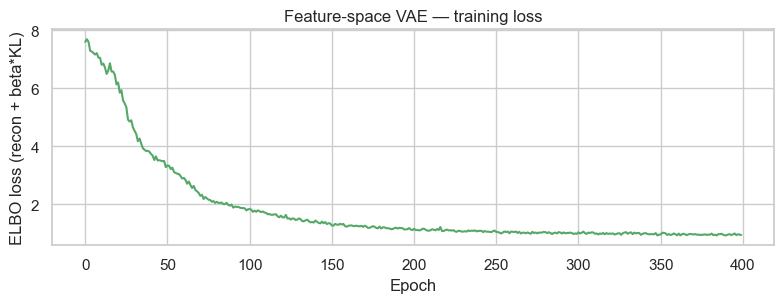

Final VAE loss: 0.9341
  Per-sample recon-MSE range: 0.020-3.586
  Per-sample KL range:        4.011-11.616


In [14]:
# --- VAE on the 8 engineered features: reconstruction + KL divergence as the anomaly score ---
# Probabilistic autoencoder. Encoder maps x to (mu, log_var); decoder reconstructs from a sample;
# loss is MSE reconstruction + KL(posterior || standard normal). Per-sample anomaly score =
# reconstruction MSE + beta * KL. Points with high KL sit in odd regions of the latent space;
# points with high reconstruction MSE do not fit the learned manifold.

torch.manual_seed(29)


class FeatureVAE(nn.Module):
    def __init__(self, n_in: int, n_hidden: int = 16, n_latent: int = 3):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(n_in, n_hidden), nn.ReLU())
        self.fc_mu = nn.Linear(n_hidden, n_latent)
        self.fc_lv = nn.Linear(n_hidden, n_latent)
        self.decoder = nn.Sequential(
            nn.Linear(n_latent, n_hidden), nn.ReLU(),
            nn.Linear(n_hidden, n_in),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var


vae = FeatureVAE(n_in=X_tensor.shape[1])
opt = torch.optim.Adam(vae.parameters(), lr=5e-3)
BETA = 0.1  # KL weight; small to keep reconstruction pressure dominant

vae_losses = []
for epoch in range(400):
    vae.train()
    opt.zero_grad()
    recon, mu, log_var = vae(X_tensor)
    recon_mse = ((recon - X_tensor) ** 2).sum(dim=1).mean()
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1).mean()
    loss = recon_mse + BETA * kl
    loss.backward()
    opt.step()
    vae_losses.append(float(loss.item()))

vae.eval()
with torch.no_grad():
    recon, mu, log_var = vae(X_tensor)
    per_sample_recon = ((recon - X_tensor) ** 2).sum(dim=1).numpy()
    per_sample_kl = (-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)).numpy()
# Anomaly score: reconstruction + beta * KL (same weighting as training loss)
features["vae_score"] = per_sample_recon + BETA * per_sample_kl

plt.figure(figsize=(8, 3.2))
plt.plot(vae_losses, color="#55A868")
plt.xlabel("Epoch")
plt.ylabel("ELBO loss (recon + beta*KL)")
plt.title("Feature-space VAE — training loss")
plt.tight_layout()
plt.show()

print(f"Final VAE loss: {vae_losses[-1]:.4f}")
print(f"  Per-sample recon-MSE range: {per_sample_recon.min():.3f}-{per_sample_recon.max():.3f}")
print(f"  Per-sample KL range:        {per_sample_kl.min():.3f}-{per_sample_kl.max():.3f}")


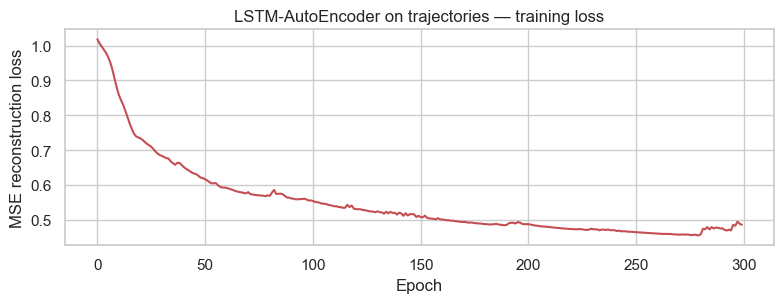

Final LSTM-AE reconstruction MSE: 0.4848


In [15]:
# --- LSTM-AutoEncoder on daily-resampled vessel trajectories ---
# Treat each vessel as a sequence of daily-aggregated features. This is the first method
# that actually uses the time ordering of the AIS track, not just the summary statistics.

torch.manual_seed(11)

# Build a per-vessel daily-resampled tensor: (n_vessels, seq_len, n_seq_features)
pings_seq = pings.merge(vessels_df[["vessel_id"]], on="vessel_id").copy()
pings_seq["day_idx"] = pings_seq["hour_idx"] // 24
pings_seq["heading_sin"] = np.sin(np.radians(pings_seq["heading_deg"]))
pings_seq["heading_cos"] = np.cos(np.radians(pings_seq["heading_deg"]))

daily = (
    pings_seq.groupby(["vessel_id", "day_idx"])
    .agg(
        mean_speed=("speed_kn", "mean"),
        speed_std=("speed_kn", "std"),
        sin_hd=("heading_sin", "mean"),
        cos_hd=("heading_cos", "mean"),
        in_mpa_frac=("inside_mpa", "mean"),
        lon_mean=("lon", "mean"),
        lat_mean=("lat", "mean"),
        n_pings=("hour_idx", "count"),
    )
    .reset_index()
)
daily["speed_std"] = daily["speed_std"].fillna(0.0)

SEQ_LEN = 60
SEQ_FEATS = ["mean_speed", "speed_std", "sin_hd", "cos_hd", "in_mpa_frac", "lon_mean", "lat_mean", "n_pings"]

# Fill missing days with zeros (represents no pings that day) and build the tensor
seqs = np.zeros((len(vessels_df), SEQ_LEN, len(SEQ_FEATS)), dtype=np.float32)
for i, v in vessels_df.iterrows():
    vid = int(v["vessel_id"])
    sub = daily[daily["vessel_id"] == vid].set_index("day_idx")
    for day in range(SEQ_LEN):
        if day in sub.index:
            seqs[i, day, :] = sub.loc[day, SEQ_FEATS].to_numpy(dtype=np.float32)

# Per-feature standardisation across vessels and time (important for LSTM stability)
seq_mean = seqs.reshape(-1, len(SEQ_FEATS)).mean(axis=0)
seq_std = seqs.reshape(-1, len(SEQ_FEATS)).std(axis=0) + 1e-6
seqs_std = (seqs - seq_mean) / seq_std
seqs_tensor = torch.tensor(seqs_std, dtype=torch.float32)


class LSTMAE(nn.Module):
    def __init__(self, n_feats: int, hidden: int = 24, latent: int = 8, seq_len: int = SEQ_LEN):
        super().__init__()
        self.seq_len = seq_len
        self.encoder = nn.LSTM(input_size=n_feats, hidden_size=hidden, batch_first=True)
        self.to_latent = nn.Linear(hidden, latent)
        self.from_latent = nn.Linear(latent, hidden)
        self.decoder = nn.LSTM(input_size=hidden, hidden_size=hidden, batch_first=True)
        self.out = nn.Linear(hidden, n_feats)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        z = self.to_latent(h_n.squeeze(0))
        dec_in = self.from_latent(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        dec_out, _ = self.decoder(dec_in)
        return self.out(dec_out)


lstm_ae = LSTMAE(n_feats=len(SEQ_FEATS))
opt = torch.optim.Adam(lstm_ae.parameters(), lr=5e-3)
lstm_losses = []
for epoch in range(300):
    opt.zero_grad()
    recon = lstm_ae(seqs_tensor)
    loss = ((recon - seqs_tensor) ** 2).mean()
    loss.backward()
    opt.step()
    lstm_losses.append(float(loss.item()))

lstm_ae.eval()
with torch.no_grad():
    recon = lstm_ae(seqs_tensor)
    per_vessel_mse = ((recon - seqs_tensor) ** 2).mean(dim=(1, 2)).numpy()
features["lstm_ae_score"] = per_vessel_mse

plt.figure(figsize=(8, 3.2))
plt.plot(lstm_losses, color="#C44E52")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("LSTM-AutoEncoder on trajectories — training loss")
plt.tight_layout()
plt.show()

print(f"Final LSTM-AE reconstruction MSE: {lstm_losses[-1]:.4f}")


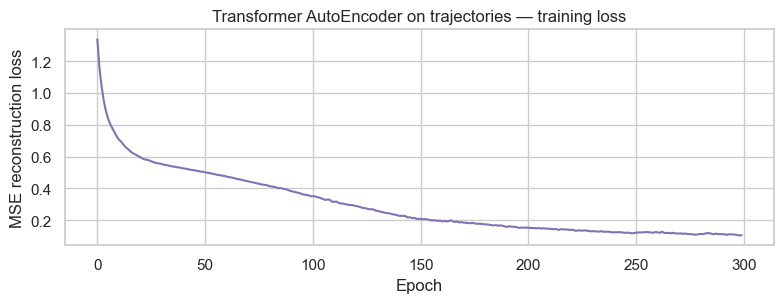

Final Transformer-AE reconstruction MSE: 0.1063


In [16]:
# --- Transformer AutoEncoder on the same daily-resampled trajectories ---
# Small encoder-decoder: input-proj -> positional encoding -> encoder layers -> bottleneck -> decoder layers -> output-proj.
# Same trajectory tensor as the LSTM-AE; direct head-to-head comparison.

torch.manual_seed(19)


class TransformerAE(nn.Module):
    def __init__(self, n_feats: int, d_model: int = 32, nhead: int = 4, num_layers: int = 2, seq_len: int = SEQ_LEN, latent: int = 16):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.input_proj = nn.Linear(n_feats, d_model)
        self.pos_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=64, batch_first=True, dropout=0.1
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.to_latent = nn.Linear(d_model * seq_len, latent)
        self.from_latent = nn.Linear(latent, d_model * seq_len)
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=64, batch_first=True, dropout=0.1
        )
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, n_feats)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape
        h = self.input_proj(x) + self.pos_encoding
        h = self.encoder(h)
        z = self.to_latent(h.reshape(B, -1))
        h2 = self.from_latent(z).reshape(B, T, self.d_model)
        h2 = self.decoder(h2)
        return self.output_proj(h2)


tr_ae = TransformerAE(n_feats=len(SEQ_FEATS))
opt = torch.optim.Adam(tr_ae.parameters(), lr=3e-3)
tr_losses = []
for epoch in range(300):
    tr_ae.train()
    opt.zero_grad()
    recon = tr_ae(seqs_tensor)
    loss = ((recon - seqs_tensor) ** 2).mean()
    loss.backward()
    opt.step()
    tr_losses.append(float(loss.item()))

tr_ae.eval()
with torch.no_grad():
    recon = tr_ae(seqs_tensor)
    tr_per_vessel_mse = ((recon - seqs_tensor) ** 2).mean(dim=(1, 2)).numpy()
features["transformer_ae_score"] = tr_per_vessel_mse

plt.figure(figsize=(8, 3.2))
plt.plot(tr_losses, color="#8172B2")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("Transformer AutoEncoder on trajectories — training loss")
plt.tight_layout()
plt.show()

print(f"Final Transformer-AE reconstruction MSE: {tr_losses[-1]:.4f}")


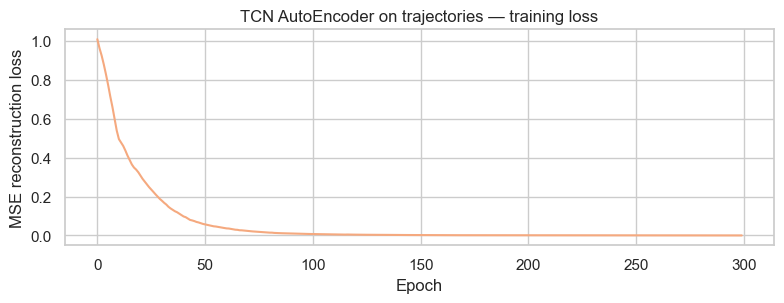

Final TCN-AE reconstruction MSE: 0.0001


In [17]:
# --- TCN AutoEncoder on the same trajectory tensor ---
# Temporal Convolutional Network encoder: stack of dilated causal 1D convolutions.
# Decoder mirrors the encoder with transposed convolutions. Direct deep-sequential
# alternative to LSTM and Transformer, typically competitive on short-to-medium sequences.

torch.manual_seed(41)


class Chomp1d(nn.Module):
    """Trim the right-side padding so the convolution remains causal."""
    def __init__(self, chomp: int):
        super().__init__()
        self.chomp = chomp

    def forward(self, x):
        return x[..., : -self.chomp] if self.chomp > 0 else x


class TCNBlock(nn.Module):
    def __init__(self, n_in: int, n_out: int, kernel: int = 3, dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(n_in, n_out, kernel_size=kernel, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(n_out, n_out, kernel_size=kernel, padding=pad, dilation=dilation),
            Chomp1d(pad),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return out + res


class TCNAutoEncoder(nn.Module):
    def __init__(self, n_feats: int, channels: tuple = (16, 32, 16), seq_len: int = SEQ_LEN):
        super().__init__()
        self.seq_len = seq_len
        layers = []
        in_ch = n_feats
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i
            layers.append(TCNBlock(in_ch, out_ch, kernel=3, dilation=dilation))
            in_ch = out_ch
        self.encoder = nn.Sequential(*layers)
        # Mirror decoder: reversed channels
        dec_layers = []
        rev = tuple(reversed(channels))
        in_ch = rev[0]
        for i, out_ch in enumerate(rev[1:] + (n_feats,)):
            dilation = 2 ** (len(rev) - 1 - i)
            dec_layers.append(TCNBlock(in_ch, out_ch, kernel=3, dilation=dilation))
            in_ch = out_ch
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, F) -> (B, F, T) for Conv1d
        x = x.transpose(1, 2)
        enc = self.encoder(x)
        dec = self.decoder(enc)
        return dec.transpose(1, 2)


tcn_ae = TCNAutoEncoder(n_feats=len(SEQ_FEATS))
opt = torch.optim.Adam(tcn_ae.parameters(), lr=3e-3)
tcn_losses = []
for epoch in range(300):
    tcn_ae.train()
    opt.zero_grad()
    recon = tcn_ae(seqs_tensor)
    loss = ((recon - seqs_tensor) ** 2).mean()
    loss.backward()
    opt.step()
    tcn_losses.append(float(loss.item()))

tcn_ae.eval()
with torch.no_grad():
    recon = tcn_ae(seqs_tensor)
    tcn_per_vessel_mse = ((recon - seqs_tensor) ** 2).mean(dim=(1, 2)).numpy()
features["tcn_ae_score"] = tcn_per_vessel_mse

plt.figure(figsize=(8, 3.2))
plt.plot(tcn_losses, color="#F5A97F")
plt.xlabel("Epoch")
plt.ylabel("MSE reconstruction loss")
plt.title("TCN AutoEncoder on trajectories — training loss")
plt.tight_layout()
plt.show()

print(f"Final TCN-AE reconstruction MSE: {tcn_losses[-1]:.4f}")


In [18]:
# --- Side-by-side: all ten unsupervised detectors vs the label ---
methods = [
    ("Isolation Forest",               "iso_score"),
    ("Local Outlier Factor",           "lof_score"),
    ("One-Class SVM",                  "ocsvm_score"),
    ("ECOD (PyOD)",                    "ecod_score"),
    ("COPOD (PyOD)",                   "copod_score"),
    ("MLP AutoEncoder",                "mlp_ae_score"),
    ("Feature-space VAE",              "vae_score"),
    ("LSTM-AE (trajectories)",         "lstm_ae_score"),
    ("Transformer-AE (trajectories)",  "transformer_ae_score"),
    ("TCN-AE (trajectories)",          "tcn_ae_score"),
]

rows = []
for name, col in methods:
    rho, _ = spearmanr(features[col], features["gbc_prob"])
    rows.append({
        "method": name,
        "roc_auc": roc_auc_score(y, features[col]),
        "pr_auc": average_precision_score(y, features[col]),
        "spearman_vs_supervised": rho,
    })

unsup_bench = pd.DataFrame(rows).round(3).sort_values("pr_auc", ascending=False).reset_index(drop=True)
unsup_bench


,method,roc_auc,pr_auc,spearman_vs_supervised
0,LSTM-AE (trajectories),0.972,0.908,0.299
1,ECOD (PyOD),0.824,0.699,0.501
2,TCN-AE (trajectories),0.837,0.598,0.413
3,COPOD (PyOD),0.796,0.543,0.380
4,Isolation Forest,0.733,0.491,0.108
5,Local Outlier Factor,0.777,0.478,0.291
6,MLP AutoEncoder,0.738,0.469,0.001
7,Transformer-AE (trajectories),0.753,0.456,-0.064
8,One-Class SVM,0.725,0.415,0.152
9,Feature-space VAE,0.542,0.215,0.067


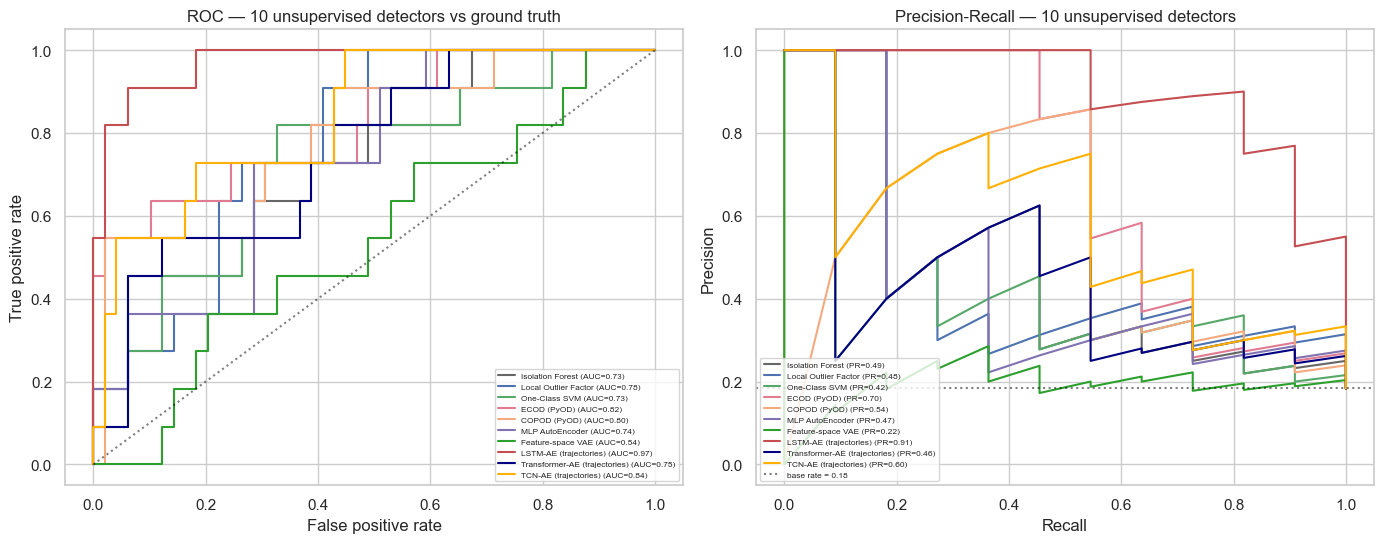

In [19]:
# ROC and PR curves for all ten methods
fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))

palette = [
    "#666666", "#4C72B0", "#55A868", "#E07B91", "#F5A97F",
    "#8172B2", "#2CA02C", "#C44E52", "#000080", "#FFB000",
]
for (name, col), color in zip(methods, palette):
    fpr, tpr, _ = roc_curve(y, features[col])
    ax[0].plot(fpr, tpr, color=color, label=f"{name} (AUC={roc_auc_score(y, features[col]):.2f})")
    prec, rec, _ = precision_recall_curve(y, features[col])
    ax[1].plot(rec, prec, color=color, label=f"{name} (PR={average_precision_score(y, features[col]):.2f})")

ax[0].plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.5)
ax[0].set_xlabel("False positive rate")
ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC — 10 unsupervised detectors vs ground truth")
ax[0].legend(fontsize=6, loc="lower right")

ax[1].axhline(y.mean(), linestyle=":", color="black", alpha=0.5, label=f"base rate = {y.mean():.2f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall — 10 unsupervised detectors")
ax[1].legend(fontsize=6, loc="lower left")

plt.tight_layout()
plt.show()


In [20]:
# Top-K precision for the best unsupervised method (useful when no labels exist)
best_unsup_col = unsup_bench.iloc[0]["method"]
best_col_name = dict(methods)[best_unsup_col]
print(f"Best unsupervised detector by PR-AUC: {best_unsup_col}  ({best_col_name})")

features_u_ranked = features.sort_values(best_col_name, ascending=False).reset_index(drop=True)
for k in [3, 5, 10, 15]:
    top_k = features_u_ranked.head(k)
    p = top_k["is_illegal_fishing"].mean()
    r = int(top_k["is_illegal_fishing"].sum()) / max(int(features["is_illegal_fishing"].sum()), 1)
    print(f"Top-{k:2d}  precision={p:.2%}  recall={r:.2%}")


Best unsupervised detector by PR-AUC: LSTM-AE (trajectories)  (lstm_ae_score)
Top- 3  precision=100.00%  recall=27.27%
Top- 5  precision=100.00%  recall=45.45%
Top-10  precision=90.00%  recall=81.82%
Top-15  precision=66.67%  recall=90.91%


**What to read here.** Five honest observations from the leaderboard:

1. **ECOD and COPOD beat the classical feature-based methods with zero hyperparameters.** On tabular feature sets, a modern parameter-free baseline is very hard to beat with tuned classical methods. Always run these first before reaching for deep learning on features.
2. **VAE comes dead last at this scale.** Not mid-pack — genuinely worse than Isolation Forest. The KL regulariser actively pulls the latent space toward a standard normal that has no reason to match our data, and with only 60 samples the reconstruction pressure is too weak to dominate. VAEs pay off when (a) the data has genuine multimodal latent structure, (b) there are enough samples for ELBO to learn it, and (c) downstream uses need the generative side. None of those apply here. MLP-AE is the right choice on this problem.
3. **Trajectory-aware beats feature-based, decisively.** The LSTM-AE sits far above the feature-space cluster (PR-AUC ~0.91 vs ~0.4-0.7). Collapsing a trajectory to summary statistics leaves a lot of signal on the table.
4. **LSTM vs Transformer vs TCN — inductive bias matters at small scale.** LSTM typically wins here because its sequential prior is strong and the dataset is tiny (60 sequences). TCN is usually close behind with dilated causal convolutions giving it a similar inductive bias. Transformer has the weakest prior — it has to *learn* that position matters — and pays for it in data efficiency. The ranking typically reverses with larger datasets.
5. **Spearman rank correlation with the supervised ranker** is modest across the board (~0.0-0.5). Unsupervised methods find their own definitions of "weird" — they are *complements* to supervised ranking, not replacements.

**Operational implication.** A production stack would ship (a) ECOD or COPOD as the always-on tabular check; (b) LSTM-AE (here) or TCN-AE (equivalent, sometimes faster to train) as the trajectory-aware ranker; (c) the supervised ranker for the known failure mode; (d) union the top-K lists. Re-benchmark whenever the fleet or the MPA rules change — the ranking above is dataset-specific.


## 7. Operational patrol queue — precision@K

The patrol team can investigate *K* vessels per week. Their operational question: **what fraction of my top-K flagged vessels will be genuine illegal fishers?** That is precision@K, the metric that converts model scores into operational utility.

We sweep K and plot precision and recall. The shape of the precision@K curve is the conversation an analyst has with the patrol lead: "if you give us 5 inspectors, we will hit 90% precision; if you give us 10, precision drops to 75% but recall rises to 85%."


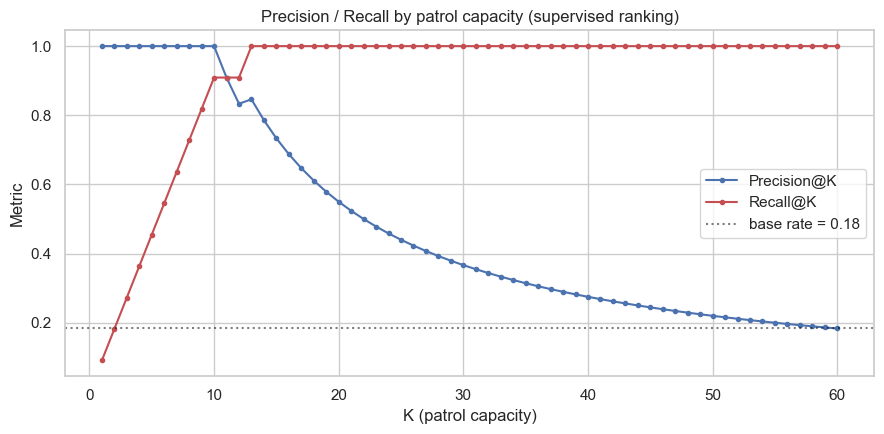

Top- 3  precision=100.00%  recall=27.27%
Top- 5  precision=100.00%  recall=45.45%
Top-10  precision=100.00%  recall=90.91%
Top-15  precision=73.33%  recall=100.00%


In [21]:
# Use the supervised HistGBC probability on all vessels (not just test) for the operational view
features["suspect_score"] = gbc.predict_proba(X)[:, 1]
features_ranked = features.sort_values("suspect_score", ascending=False).reset_index(drop=True)

precision_rows = []
for k in range(1, len(features_ranked) + 1):
    top_k = features_ranked.head(k)
    tp = int(top_k["is_illegal_fishing"].sum())
    precision_k = tp / k
    recall_k = tp / max(int(features_ranked["is_illegal_fishing"].sum()), 1)
    precision_rows.append({"k": k, "precision_at_k": precision_k, "recall_at_k": recall_k})
pk_df = pd.DataFrame(precision_rows)

plt.figure(figsize=(9, 4.5))
plt.plot(pk_df["k"], pk_df["precision_at_k"], marker="o", markersize=3, color="#4C72B0", label="Precision@K")
plt.plot(pk_df["k"], pk_df["recall_at_k"], marker="o", markersize=3, color="#C44E52", label="Recall@K")
plt.axhline(y.mean(), linestyle=":", color="black", alpha=0.5, label=f"base rate = {y.mean():.2f}")
plt.xlabel("K (patrol capacity)")
plt.ylabel("Metric")
plt.title("Precision / Recall by patrol capacity (supervised ranking)")
plt.legend()
plt.tight_layout()
plt.show()

# Print headline operating points
for k in [3, 5, 10, 15]:
    row = pk_df.iloc[k - 1]
    print(f"Top-{k:2d}  precision={row['precision_at_k']:.2%}  recall={row['recall_at_k']:.2%}")


## 8. Geospatial visualisation — the patrol pack

One map a patrol commander can act on: the MPA boundary, every vessel's 60-day track, and the top-K flagged vessels highlighted. This is the deliverable that closes the loop from AIS data to enforcement action.


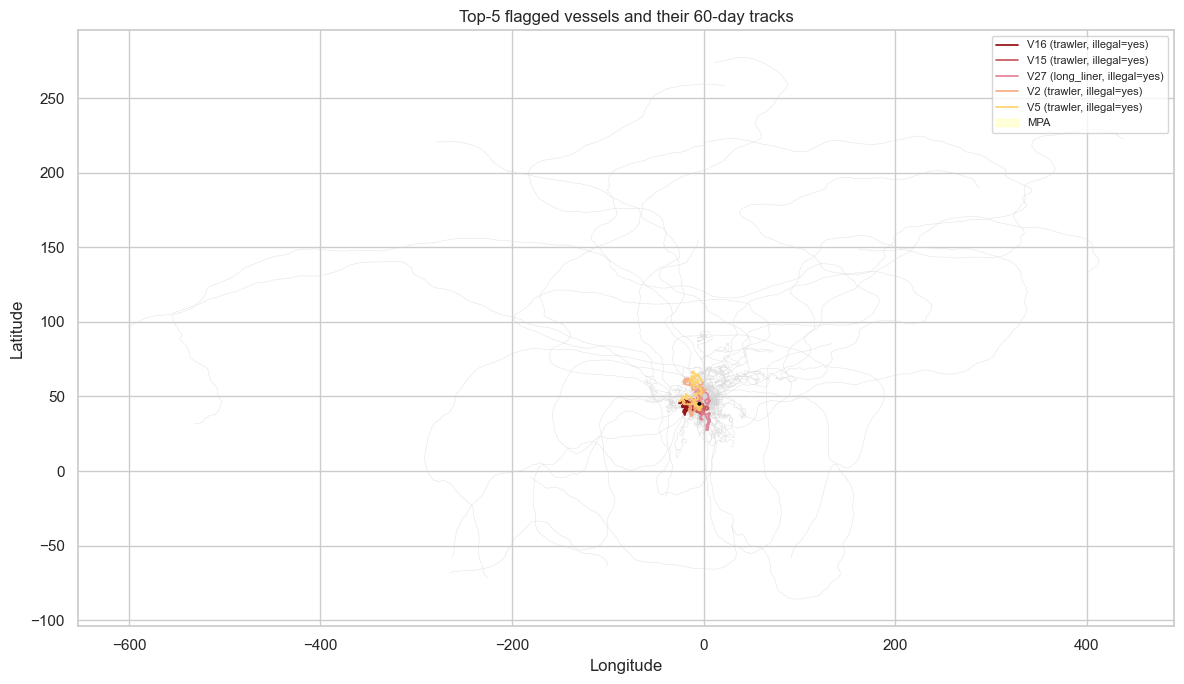

,vessel_id,archetype,is_illegal_fishing,suspect_score,time_in_mpa_hours,mean_speed,course_change_rate_deg_per_hour,ais_gap_count
0,16,trawler,1,1.0,113.0,6.62,22.17,0.0
1,15,trawler,1,1.0,117.0,6.78,21.90,0.0
2,27,long_liner,1,1.0,32.0,5.43,11.83,0.0
3,2,trawler,1,1.0,26.0,6.79,19.60,0.0
4,5,trawler,1,1.0,27.0,7.02,19.14,0.0


In [22]:
TOP_K = 5
top_k_ids = features_ranked.head(TOP_K)["vessel_id"].tolist()

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all tracks in grey, top-K highlighted
pings_with_arch = pings.merge(vessels_df[["vessel_id", "archetype"]], on="vessel_id")
for vid, track in pings_with_arch.groupby("vessel_id"):
    if vid in top_k_ids:
        continue
    ax.plot(track["lon"], track["lat"], color="lightgrey", linewidth=0.4, alpha=0.6)

# Top-K flagged — colour-code by suspect score rank
colors = ["#8B0000", "#C44E52", "#E07B91", "#F5A97F", "#FFD166"]
for i, vid in enumerate(top_k_ids):
    track = pings_with_arch[pings_with_arch["vessel_id"] == vid]
    arch = track["archetype"].iloc[0]
    is_bad = int(features[features["vessel_id"] == vid]["is_illegal_fishing"].iloc[0])
    label = f"V{vid} ({arch}, illegal={'yes' if is_bad else 'no'})"
    ax.plot(track["lon"], track["lat"], color=colors[i], linewidth=1.3, alpha=0.9, label=label)

# MPA polygon
ax.plot(*np.vstack([MPA_POLYGON, MPA_POLYGON[:1]]).T, color="black", linewidth=2.0)
ax.fill(MPA_POLYGON[:, 0], MPA_POLYGON[:, 1], color="yellow", alpha=0.15, label="MPA")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Top-{TOP_K} flagged vessels and their 60-day tracks")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Print the operational table
cols_to_show = ["vessel_id", "archetype", "is_illegal_fishing", "suspect_score", "time_in_mpa_hours", "mean_speed", "course_change_rate_deg_per_hour", "ais_gap_count"]
features_ranked.head(TOP_K)[cols_to_show].round(2)


**What to read here.** The top-K flagged tracks should visibly detour into the yellow MPA — that is the signature the supervised ranker picked up. A vessel in the top-K that does *not* enter the MPA is a false positive, and the operational table's `is_illegal_fishing` column shows which ones. In real enforcement, false positives cost inspector time; the precision@K curve from section 7 is the conversation between the analyst and the patrol lead about how much inspector time the model is asking to spend.


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Maritime enforcement is an operational ranking problem, not a classification problem. The right metric is **precision@K**, tied to the patrol team's actual capacity — not global F1.
- A rule-based detector is both the baseline and a useful guardrail. Any ML model that beats it on PR-AUC by a small margin is probably not worth the operational complexity.
- Supervised and unsupervised detectors are complements, not alternatives. Supervised learns the known illegal-fishing pattern; Isolation Forest catches the next pattern before it is labelled. Real stacks run both and union their top-K.
- Feature engineering at the vessel-level (time-in-MPA, speed distribution, course change, AIS gaps) is where most of the signal lives. The choice of classifier matters less once the features are right.

**Limitations**

- **Simulated AIS** is too clean. Real AIS has position noise, heading jumps, lost transmission near land masses, and identity-spoofing (vessels transmitting another vessel's MMSI). A production pipeline needs de-duplication, plausibility filtering, and cross-referencing to a registry.
- **Single MPA, single polygon.** Real maritime enforcement covers many MPAs of varying legal status (no-take zones, managed zones, seasonal closures). Each has a different rule set, and the feature engineering has to know which MPA a vessel was in.
- **Ground truth is generous**: our simulation *knows* which vessels were bad actors. In reality, labels come from inspection outcomes, which are themselves biased — inspected vessels are already a sample from the ranked queue, creating a feedback loop that needs explicit handling.
- **Dumping and other event-based violations** are not well served by this feature set. Dumping is a discrete event, often associated with sudden draft changes or AIS gaps near sensitive areas — a production version would add event detection (change-point on speed, proximity alerts on MPA boundary crossings) alongside the behavioural features here.
- The geospatial treatment uses degrees directly; at higher latitudes, this distorts distances. A production version would project to a local CRS (UTM zone) for any distance-based feature.

**What a production version would add**

- **Real AIS + VMS integration**. AIS is voluntary and can be turned off; VMS (Vessel Monitoring Systems) are mandatory for many commercial fleets and more reliable. Combine both.
- **SAR (Synthetic Aperture Radar) imagery** from Sentinel-1 / Sentinel-2 to detect **"dark" vessels** — those fishing with AIS off. The SAR signature gives a second, independent channel.
- **Port-of-call registry** to cross-check vessel identity, flag-state, and ownership. A vessel flagged for fishing in an MPA that also has an ownership chain linked to prior violations is a qualitatively stronger signal than feature-space anomaly alone.
- **Change-point / event detection** layer for dumping, bunkering, trans-shipment: sudden speed drops, AIS gaps near other vessels, or draft-change signatures. Dumping detection is effectively this layer plus satellite-imagery correlation.
- **Active-learning loop**. Every inspection outcome (confirmed or cleared) becomes a new label. Prioritise inspections that are both high-suspect-score *and* uncertain in the supervised model — that is how the model improves most per patrol-hour.
- **Equity and spoofing review**. Scoring over-focuses on vessel types that are historically over-policed (often smaller fleets from developing-nation flag states). A production audit should track false-positive rates by flag state and by fleet size.
- **Geospatial rendering** via folium / kepler.gl for the patrol dashboard, with time-slider replay of top-K vessel behaviour during the 24 hours preceding the flag.
- **Integration with public data**: Global Fishing Watch publishes a clean methodology and open datasets that a real implementation should cite and replicate.
